In [58]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u

from analysis_electrons.general_spectrum_analysis import volume_approximation
from config.plotting import set_plotting_defaults, Tab10
from config.units import Gauss, flux_unit
from analysis_protons.spectrum_fit_protons import OnlyProtonSpectrumFit, ProtonSecondaryElectrons
from config.settings import MCMC_PROTONS, SPECTRUM_DIR, SYNCH_INTERP_DIR

set_plotting_defaults()

In [59]:
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))
names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data

In [60]:
nsteps, nwalkers = 2000, 64
data = pickle.load(open(os.path.join(MCMC_PROTONS, f"protons_{nsteps}n_{nwalkers}w.pck"), "rb"))
result, psf = data[0], data[1]

In [61]:
sec_energy = np.logspace(6, 16, 1000) * u.eV
pse = ProtonSecondaryElectrons(proton_energy=psf.proton_energy,
                               sec_energy=sec_energy)
pse.spectrum = psf.spectrum

cs calculation
ready


In [62]:
result_mod = result[(result[:, 1] > 1) * (result[:, 2] > 2.5) * (result[:, 2] < 5.0)]

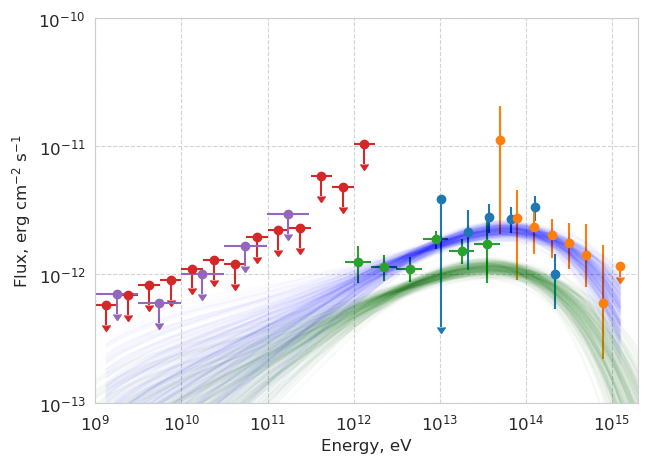

In [63]:
for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0,
                 color=Tab10[i], label=f' ')

for res in result_mod[::10]:
    plt.plot(psf.photon_energy, psf.model(res), alpha=.01, color='blue')
    sec_flux = pse.sec_flux(pse.sec_density(res, 'el') + pse.sec_density(res, 'posi'))
    plt.plot(pse.sec_energy, sec_flux, alpha=.01, color='green')

plt.xscale('log')
plt.xlim(1e9, 2e15)
plt.xlabel("Energy, eV")

plt.yscale('log')
plt.ylim(1e-13, 1e-10)
plt.ylabel(r"Flux, $\mathrm{erg~cm^{-2}~s^{-1}}$")
# save_figure("spectrum_with_a_proton_fit_mcmc")
plt.show()

[0.91289013 1.6314668  3.72319711]


<Figure size 1000x800 with 0 Axes>

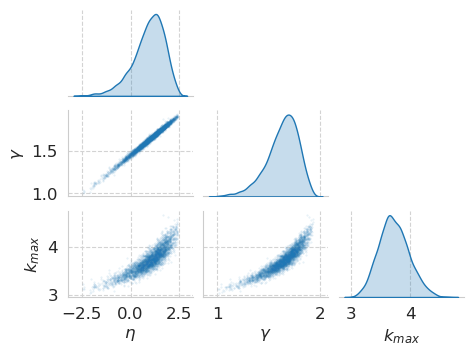

In [64]:
columns = [r"$\eta$", r"$\gamma$", r"$k_{max}$"]
fs = pd.DataFrame(result_mod, columns=columns)
print(np.mean(result_mod, axis=0))

plt.figure(figsize=(10, 8))
sns.pairplot(fs, diag_kind="kde",
             plot_kws=dict(marker=".", linewidth=0, alpha=.1, s=10),
             corner=True, height=1.2, aspect=4/3)
# g.map_lower(sns.kdeplot, levels=5, color=".2", alpha=.3)

In [65]:
# SYNCHROTRON RADIATON SETTING
bfield = 14e-6 * Gauss
synch_photon_energy = np.logspace(-8, 15, 100) * u.eV

e_volume = volume_approximation(pse.sec_energy)

path = os.path.join(SYNCH_INTERP_DIR, f"synch_power_interp_{bfield.value * 1e6:.1f}.pck")
synch_interp_data = pickle.load(open(path, "rb"))

synch_interp = synch_interp_data[2]

lg_ee = np.log10(pse.sec_energy.value)
lg_pe = np.log10(synch_photon_energy.value)

ee_pe, pe_ee = np.meshgrid(lg_ee, lg_pe, indexing='ij')
synch_table = 10**synch_interp((ee_pe, pe_ee)) * (1/u.s)

In [66]:
result_chosen = result_mod[::50]

synch_flux_fast = np.zeros([result_chosen.shape[0], synch_photon_energy.size]) * flux_unit
sec_flux_tot = np.zeros([result_chosen.shape[0], pse.sec_energy.size]) * flux_unit

for i, res_i in enumerate(result_chosen):
    sec_density = pse.sec_density(res_i, 'el') + pse.sec_density(res_i, 'posi')
    sec_flux = pse.sec_flux(sec_density)
    synch_lum = np.trapezoid(synch_table.T * sec_density * (10 * u.kyr), pse.sec_energy, axis=1)
    synch_flux_fast[i] = synch_lum * synch_photon_energy / pse.area
    sec_flux_tot[i] = sec_flux

### ATTENTION!

This result does not resemble (in any shape or form) the result from Neronov-Oikonomou-Semikoz 2024 paper...\

Try *cooling* the electron spectrum with the synchrotron / inverse Compton losses and see what happens...

In [69]:
new_photon_energy = np.logspace(7, 19, 100) * u.eV

psf.photon_energy = new_photon_energy
(psf.e_prim, psf.above_cutoff, psf.below_cutoff,
psf.e_sec,
psf.he_cs_matrix, psf.le_cs_matrix) = psf.get_cs_matrices()

In [70]:
ans = []
for i, res_i in enumerate(result_chosen):
    ans.append(psf.model(res_i))

[1.5596786  1.76569448 3.87764661]


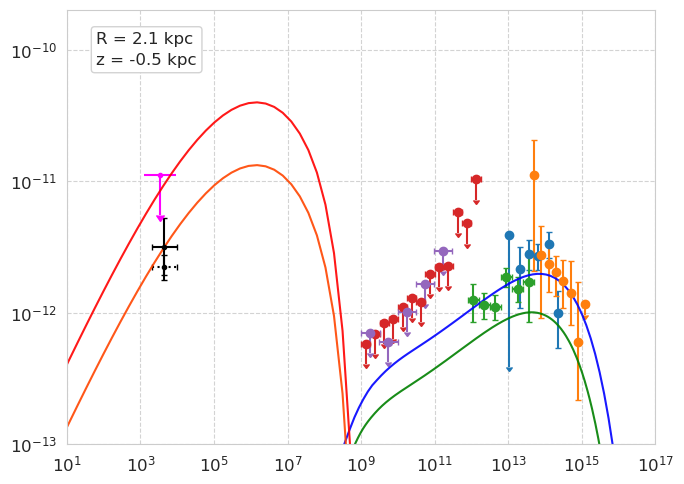

In [81]:
from spectrum.measurements_xray import constraint_XRISM, constraint_Chandra, weak_constraint_XRISM

# UHE spectrum
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))
names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data
names_short = ["HAWC", "LHAASO", "H.E.S.S.", "FERMI\n[Semikoz et al.]", "FERMI [Zhao et al.]"]

set_plotting_defaults()
plt.figure(figsize=(7, 5))
for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0, capsize=2,
                 color=Tab10[i], label=names_short[i])
# X-Ray corrected
e, f, f_l, f_p, e_l, e_p = constraint_XRISM()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p], color='black', capsize=2,
             marker='o', markersize=3, label='XRISM', linestyle='None')
e, f, f_l, f_p, e_l, e_p = weak_constraint_XRISM()
eb = plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p], color='black', capsize=2,
                  marker='o', markersize=3, label='XRISM\n(no background)', linestyle='None')
eb[-1][0].set_linestyle(':')
e, f, f_l, f_p, e_l, e_p = constraint_Chandra()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=0.5 * f, uplims=True,
             marker='o', markersize=3, label='Chandra\n(from H.E.S.S.)', linestyle='None',
             color='magenta')
plt.errorbar(1, 1, linewidth=0, label=' ', marker=None)

for i, res_i in enumerate(result_chosen[49:50]):
    print(res_i)
    plt.plot(psf.photon_energy, ans[i], alpha=.9, color='blue')
    plt.plot(pse.sec_energy, sec_flux_tot[i], alpha=.9, color='green')
    plt.plot(synch_photon_energy, synch_flux_fast[i] / 3, alpha=.9, color='orangered')
    plt.loglog(synch_photon_energy, synch_flux_fast[i], alpha=.9, color='red')
    plt.ylim(1e-13, 2e-10)
    plt.xlim(1e1, 1e17)

plt.text(
    0.05, 0.95,              # X, Y in axis fraction (0–1)
    "R = 2.1 kpc\n"
    "z = -0.5 kpc",
    transform=plt.gca().transAxes,  # So coordinates are relative to the plot area
    fontsize=12,
    linespacing=1.5,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.3,rounding_size=0.2',
        facecolor='white', edgecolor='lightgray',
    )
)

plt.tight_layout()
plt.show()